# Preprocess MRI data in NIfTI format.

Extract, preprocess and stitch a single MRI reading into an image file suitable for further post-processing in Touchdesigner or other real-time visual software.

In [18]:
from sys import platform
from pathlib import Path
import os
import nibabel
import matplotlib.pyplot as plt
import imageio.v3 as iio
from natsort import natsorted

#### Functions

In [4]:
def plot_mri(img, save_img=False, save_path=None):
    plt.imshow(img, cmap='Grays_r')
    plt.axis('off')
    plt.margins(x=0)
    plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
    plt.imshow(img, cmap='Grays_r')
    if save_img:
        assert(save_path is not None), 'No path provided'
        plt.savefig(save_path, bbox_inches='tight', pad_inches=0)
    else:
        plt.show()
    plt.close()

#### System paths

In [5]:
if platform == 'linux':
    home_dir = '~'
elif platform == 'win32':
    home_dir = '%HOMEDRIVE%%HOMEPATH%'
else:
    raise ValueError("Cannot set home directory for this OS.")

print(home_dir)

%HOMEDRIVE%%HOMEPATH%


#### Data directory

In [6]:
data_dir = r'Downloads\ds004767-download'

#### Working directory

In [7]:
wk_dir = os.path.expandvars(os.path.join(home_dir, data_dir))
wk_dir

'C:\\Users\\th1si\\Downloads\\ds004767-download'

#### Open NiFTI dataset

In [8]:
# Data from OpenNeuro public MRI datasets (openneuro.org/datasets/ds004767/versions/1.0.0)
f_nifti = r'sub-00xHNL21\anat\sub-00xHNL21_T2w.nii\HNL-11-15_hippo_200um_stitch_20171017.nii' 

In [9]:
nifti_path = os.path.join(wk_dir, f_nifti)
nifti_data = nibabel.load(nifti_path)
mri = nifti_data.get_fdata() # Creates numpy.memmap object (lazy loading)

In [10]:
mri.shape

(220, 600, 197)

#### Single test image

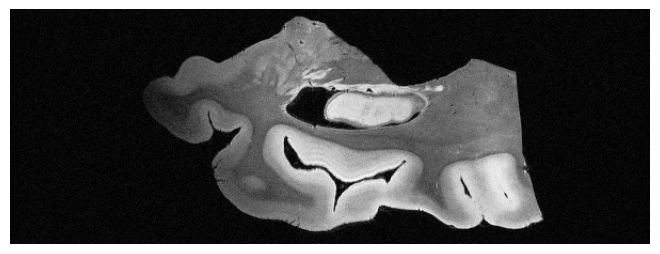

In [11]:
img = mri[:, :, 85]
img
plot_mri(img)

### Process all individual MRIs

Since the final output is intended to be ingested by Touchdesigner for real-time visual manipulation, each image will be kept separate and then all of them will be loaded to a MovieFile In Top as a numbered sequence.

In [12]:
z = mri.shape[2] # Number of images to create
z

197

In [13]:
img_dir = r'OneDrive\Pictures\ds004767' #Stupid OneDrive
img_path = os.path.expandvars(os.path.join(home_dir, img_dir))
dir_path = Path(img_path)
dir_path.mkdir(parents=True, exist_ok=True)
print(img_path)

C:\Users\th1si\OneDrive\Pictures\ds004767


In [14]:
for arr in range(z):
    img = mri[:, :, arr]
    save_path = f'{img_path}\\{arr}.jpg'
    plot_mri(img, save_img=True, save_path=save_path)
    if arr % 25 == 0:
        print(f'Saving image {arr}')
print(f'Done saving {z} images in {img_path}')

Saving image 0
Saving image 25
Saving image 50
Saving image 75
Saving image 100
Saving image 125
Saving image 150
Saving image 175
Done saving 197 images in C:\Users\th1si\OneDrive\Pictures\ds004767


#### Animate to visualize generated MRI

In [32]:
filenames = natsorted(os.listdir(img_path)) # Natural (not lexicographic) sorting
images = [iio.imread(f'{img_path}\\{f}') for f in filenames]
iio.imwrite(f'{img_path}\\ds004767.gif', images, duration=25, loop=0)